# Procrustes across cortical regions in the IBL Brainwide Map

Figure-3-style analysis of the shape-metrics paper, applied to Posani, Wang et al. (2026),
*Rarely categorical, highly separable representations along the cortical hierarchy*.

In their Fig. 2c the single-neuron selectivity profiles are **averaged** within each region.
Here we keep the whole population of each region and compare regions with the Procrustes
shape distance instead.

All the work happens in `code/`; this notebook only calls it.
Run `extract_selectivity.py` once first to produce `rrr_neurons.npz`.

In [1]:
import sys
sys.path.insert(0, "code")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import data, shape, plotting

d = data.Dataset()
print(d)
print(", ".join(f"{a}({n})" for a, n in zip(d.regions, d.counts)))

Dataset(4617 selective neurons, 22 regions)
VISp(160), AUDp(164), SSp-ll(74), SSp-n(191), SSp-ul(100), SSp-m(465), SSp-bfd(185), SSs(269), SSp-tr(92), MOp(754), RSPv(87), RSPd(68), GU(76), ORBl(67), AId(144), VISpm(77), PL(103), VISa(316), VISam(76), MOs(383), ORBvl(121), ACAd(120)


## 1. Shape distances between regions

Each region gives a *conditions x neurons* matrix. In `temporal` mode the conditions are
the 8 task variables x 100 time bins of the RRR encoding model, so a column is one neuron's
tuning. Each matrix is reduced to 25 PCs and normalised, then

$$d(X, Y) = \min_{Q\ \mathrm{orthogonal}} \lVert X - YQ \rVert_F$$

Every region is subsampled to 50 neurons, 20 times, so region size cannot drive the result.

In [2]:
D = shape.distance_matrix(d, mode="temporal", n_pcs=25, n_sub=50, n_repeats=20)

within = shape.split_half(d, mode="temporal", n_pcs=25, n_sub=50, n_repeats=20)
print(f"within-region (split-half): {within.mean():.3f}")
print(f"across regions:             {shape.pairs(D).mean():.3f}")

within-region (split-half): 0.602
across regions:             0.711


'figures/notebook/1_distmat.pdf'

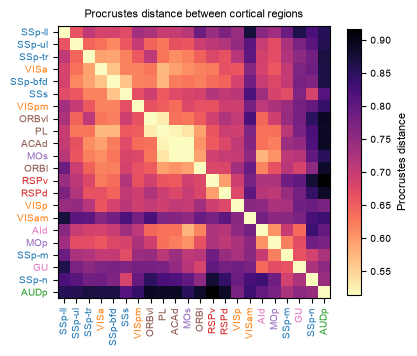

In [3]:
fig, ax = plt.subplots(figsize=plotting.figsize(1, 1))
plotting.distmat(D, d, ax=ax)
ax.set_title("Procrustes distance between cortical regions")
plt.tight_layout()
plotting.save(fig, "1_distmat")

## 2. The same matrix in 2D

`shape.embed` uses classical MDS: a closed form, so the coordinates come out the same
every run. sklearn's `MDS` (SMACOF) preserves the distances just as well but starts from
a random configuration, and the individual coordinates change from run to run — which
matters below, where we use them as regressors.

'figures/notebook/2_mds.pdf'

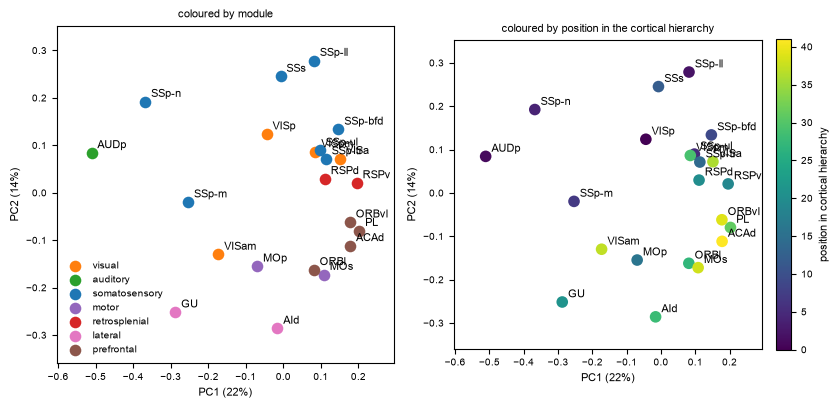

In [4]:
xy, var = shape.embed(D, n_components=10)

fig, axs = plt.subplots(1, 2, figsize=plotting.figsize(2, 1))
plotting.mds(xy, var, d, ax=axs[0], by="module")
plotting.mds(xy, var, d, ax=axs[1], by="hierarchy")
axs[0].set_title("coloured by module")
axs[1].set_title("coloured by position in the cortical hierarchy")
plt.tight_layout()
plotting.save(fig, "2_mds")

### Predicting the hierarchy from both components

Rather than correlating the hierarchy with PC1 alone, regress it on PC1 *and* PC2.
Cross-validation is leave-one-region-out: every region is predicted by a model fitted
without it.

The fitted weights define a direction in the embedding plane: the arrow points the way
the predicted hierarchy grows fastest, and regions on the same dotted line get the same
prediction.

PC1 alone:  |rho| = 0.50, p = 0.019
PC1 + PC2:  weights = [ 31.6 -55.2], in-sample R2 = 0.60, leave-one-region-out R2 = 0.50 (rho = +0.74)


'figures/notebook/3_hierarchy_pc1_pc2.pdf'

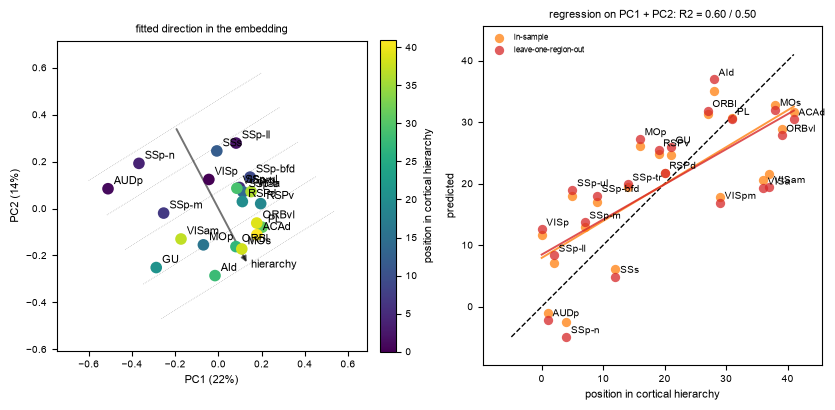

In [5]:
h = d.hierarchy()                          # position along the cortical hierarchy

rho1, p1 = spearmanr(h, xy[:, 0])          # what a single component gives
print(f"PC1 alone:  |rho| = {abs(rho1):.2f}, p = {p1:.3f}")

model = shape.fit(xy, h)                   # hierarchy ~ b1*PC1 + b2*PC2
pred_in, r2_in, _ = shape.regress(xy, h)
pred_cv, r2_cv, rho_cv = shape.cv_regress(xy, h)
print(f"PC1 + PC2:  weights = {model.coef_.round(1)}, in-sample R2 = {r2_in:.2f}, "
      f"leave-one-region-out R2 = {r2_cv:.2f} (rho = {rho_cv:+.2f})")

fig, axs = plt.subplots(1, 2, figsize=plotting.figsize(2, 1))
plotting.mds(xy, var, d, ax=axs[0], by="hierarchy")
plotting.regression_axis(axs[0], model.coef_, xy, label="hierarchy")
axs[0].set_title("fitted direction in the embedding")
plotting.prediction(h, [pred_in, pred_cv], ["in-sample", "leave-one-region-out"],
                    ax=axs[1], xlabel="position in cortical hierarchy",
                    ylabel="predicted", point_labels=d.regions,
                    title=f"regression on PC1 + PC2: R2 = {r2_in:.2f} / {r2_cv:.2f}")
plt.tight_layout()
plotting.save(fig, "3_hierarchy_pc1_pc2")

### From the whole matrix, not just two components

Classical MDS with all K-1 dimensions re-encodes the dissimilarity matrix without
losing anything, so regressing on all of them is regressing on the matrix itself.
With 21 predictors and 22 regions least squares would interpolate, so we use ridge
with the penalty chosen *inside* each training fold. The sweep below shows how the
held-out fit changes as dimensions are added; the grey band is the same regression
with the hierarchy labels shuffled.

full matrix (21 dims): in-sample R2 = 1.00, leave-one-region-out R2 = 0.39 (rho = +0.58, p = 0.000)
best sweep point: 5 dims, R2 = 0.56


'figures/notebook/4_hierarchy_full_matrix.pdf'

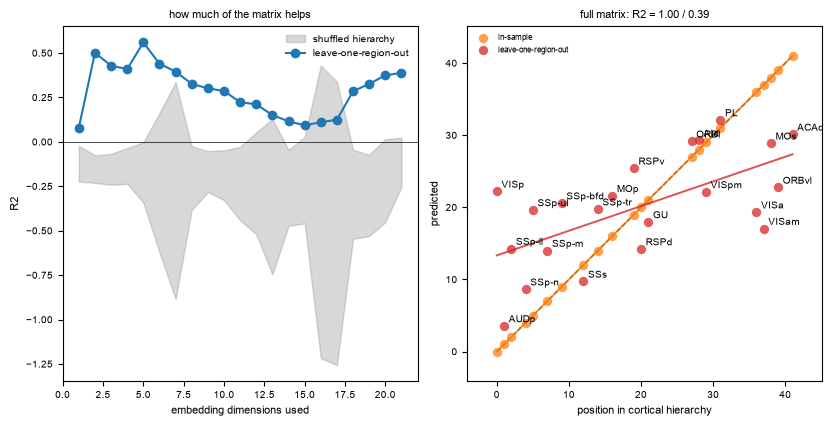

In [6]:
E = shape.classical_mds(D, n_components=len(d.regions) - 1)   # the matrix, losslessly
alphas = np.logspace(-3, 3, 13)
rng = np.random.default_rng(0)

dims = np.arange(1, E.shape[1] + 1)
curve = [shape.cv_regress(E[:, :n], h, alphas=alphas)[1] for n in dims]
null = np.array([[shape.cv_regress(E[:, :n], rng.permutation(h), alphas=alphas)[1]
                  for _ in range(50)] for n in dims])

pred_in, r2_in, _ = shape.regress(E, h)
pred_cv, r2_cv, rho_cv = shape.cv_regress(E, h, alphas=alphas)
p = (null[-1] >= r2_cv).mean()
print(f"full matrix ({E.shape[1]} dims): in-sample R2 = {r2_in:.2f}, "
      f"leave-one-region-out R2 = {r2_cv:.2f} (rho = {rho_cv:+.2f}, p = {p:.3f})")
print(f"best sweep point: {dims[np.argmax(curve)]} dims, R2 = {max(curve):.2f}")

fig, axs = plt.subplots(1, 2, figsize=plotting.figsize(2, 1))
axs[0].fill_between(dims, null.mean(1) - null.std(1), null.mean(1) + null.std(1),
                    color="gray", alpha=.3, label="shuffled hierarchy")
axs[0].plot(dims, curve, "o-", color="C0", label="leave-one-region-out")
axs[0].axhline(0, color="k", lw=.5)
axs[0].set_xlabel("embedding dimensions used"); axs[0].set_ylabel("R2")
axs[0].set_title("how much of the matrix helps"); axs[0].legend(fontsize=7, frameon=False)
axs[0].set_box_aspect(1)
plotting.prediction(h, [pred_in, pred_cv], ["in-sample", "leave-one-region-out"],
                    ax=axs[1], xlabel="position in cortical hierarchy",
                    ylabel="predicted", point_labels=d.regions,
                    title=f"full matrix: R2 = {r2_in:.2f} / {r2_cv:.2f}")
plt.tight_layout()
plotting.save(fig, "4_hierarchy_full_matrix")

Does regularisation stop the later components from contaminating the prediction?
Ridge shrinks a coordinate in proportion to how little variance it carries, so it only
helps if the later components are small — worth checking against this spectrum.

variance share per dimension: [0.155 0.094 0.081 0.069 0.061 0.054 0.048 0.047 0.043 0.038 0.036 0.034
 0.033 0.031 0.03  0.028 0.027 0.026 0.025 0.022 0.02 ]
  PC1 + PC2                  LOO R2 = +0.495   rho = +0.74
  full, least squares        LOO R2 = +0.395   rho = +0.61
  full, ridge                LOO R2 = +0.390   rho = +0.59
  full, lasso                LOO R2 = +0.270   rho = +0.61
  truncation chosen in-fold  LOO R2 = +0.278   rho = +0.62


'figures/notebook/5_regularization.pdf'

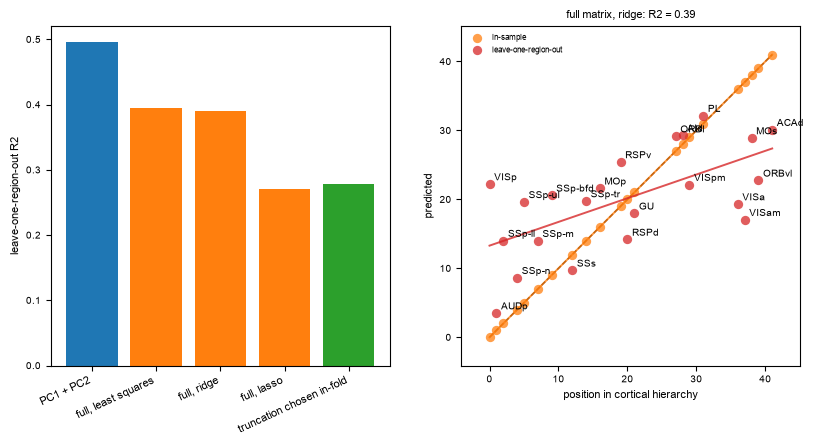

In [7]:
from sklearn.linear_model import LassoCV

ev = E.var(0)
print("variance share per dimension:", np.round(ev / ev.sum(), 3))

fits = {
    "PC1 + PC2": shape.cv_regress(E[:, :2], h),
    "full, least squares": shape.cv_regress(E, h),
    "full, ridge": shape.cv_regress(E, h, alphas=np.logspace(-6, 6, 49)),
    "full, lasso": shape.cv_regress(E, h, model=lambda: LassoCV(cv=5,
                                                             max_iter=50000)),
    "truncation chosen in-fold": shape.cv_regress_truncated(E, h)[:3],
}
for name, (_, r2, rho) in fits.items():
    print(f"  {name:26s} LOO R2 = {r2:+.3f}   rho = {rho:+.2f}")

ridge = shape.cv_regress(E, h, alphas=np.logspace(-6, 6, 49))[0]
ridge_in = shape.fit(E, h, alphas=np.logspace(-6, 6, 49)).predict(E)

fig, axs = plt.subplots(1, 2, figsize=plotting.figsize(2, 1))
ax = axs[0]
ax.bar(range(len(fits)), [v[1] for v in fits.values()],
       color=["C0"] + ["C1"] * 3 + ["C2"])
ax.set_xticks(range(len(fits)))
ax.set_xticklabels(fits, rotation=25, ha="right", fontsize=8)
ax.axhline(0, color="k", lw=.5)
ax.set_ylabel("leave-one-region-out R2")
ax.set_box_aspect(1)
plotting.prediction(h, [ridge_in, ridge], ["in-sample", "leave-one-region-out"],
                    ax=axs[1], xlabel="position in cortical hierarchy",
                    ylabel="predicted", point_labels=d.regions,
                    title=f"full matrix, ridge: R2 = {fits['full, ridge'][1]:.2f}")
plt.tight_layout()
plotting.save(fig, "5_regularization")

## 3. Regressing anatomy out of the distance matrix

The target is the log anatomical connectivity between the two regions of a pair, the same
quantity their Fig. 2d relates to averaged selectivity. Here the cross-validation holds
out a whole region at a time: all 21 pairs that touch it become the test set, so no region
is in both the training and the test set.

in-sample R2 = 0.232
leave-one-region-out R2 = 0.191, rho(true, predicted) = +0.47


'figures/notebook/6_connectivity.pdf'

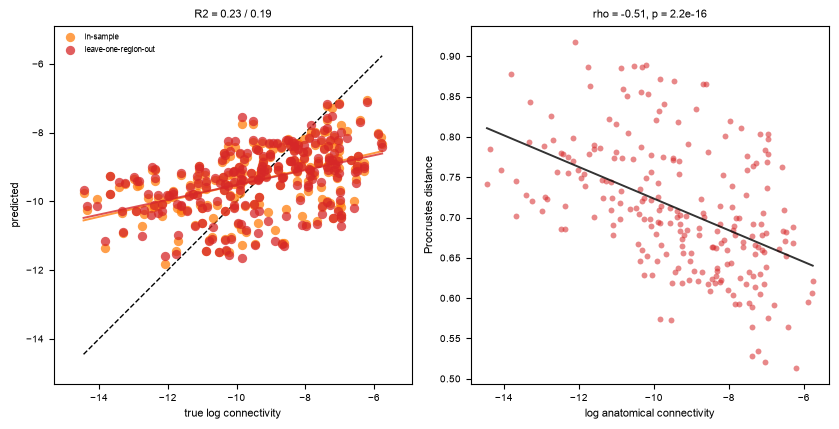

In [8]:
y = shape.pairs(d.connectivity())        # log anatomical connectivity of each pair
x = shape.pairs(D)                       # Procrustes distance of each pair

pred_in, r2_in, _ = shape.regress(x, y)
pred_cv, r2_cv, rho_cv = shape.cv_regress_pairs(x, y, len(d.regions))
print(f"in-sample R2 = {r2_in:.3f}")
print(f"leave-one-region-out R2 = {r2_cv:.3f}, rho(true, predicted) = {rho_cv:+.2f}")

fig, axs = plt.subplots(1, 2, figsize=plotting.figsize(2, 1))
plotting.prediction(y, [pred_in, pred_cv], ["in-sample", "leave-one-region-out"], ax=axs[0],
                    xlabel="true log connectivity", ylabel="predicted",
                    title=f"R2 = {r2_in:.2f} / {r2_cv:.2f}")
rho, p = spearmanr(x, y)
plotting.scatter(y, x, "log anatomical connectivity", "Procrustes distance", ax=axs[1],
                 title=f"rho = {rho:.2f}, p = {p:.1e}")
plt.tight_layout()
plotting.save(fig, "6_connectivity")

Regions that are more strongly connected anatomically have more similar population
geometry, and the relation holds for regions the model never saw. The right panel is the
same fact without a model: with a single predictor the regression *is* the correlation.

`regression.py` takes this further — richer feature sets built from the same matrix, a
permutation null, and the ordinal regression of the hierarchy.

## 4. Summary figure

Three square panels, all scored by rank correlation: the shape distance against
anatomical connectivity, the embedding, and the cross-validated ridge prediction of
hierarchy position from the whole distance matrix.

'figures/notebook/7_summary.pdf'

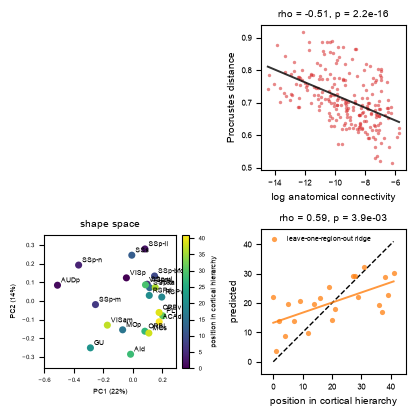

In [9]:
ridge_cv = shape.cv_regress(E, h, alphas=np.logspace(-6, 6, 49))[0]
rho_conn, p_conn = spearmanr(x, y)
rho_hier, p_hier = spearmanr(h, ridge_cv)

# sized to sit beside netrep-journal-figure-4.pdf: same 4.2 in height, half its width.
# markers and region labels shrink with the panels, which are only ~1.4 in here.
fig, axs = plt.subplots(2, 2, figsize=plotting.figsize(2, 2, panel=plotting.PAGE_HEIGHT / 2))
axs[0, 0].axis("off")                      # left free for a schematic

plotting.scatter(y, x, "log anatomical connectivity", "Procrustes distance",
                 ax=axs[0, 1], size=6, fontsize=7,
                 title=f"rho = {rho_conn:.2f}, p = {p_conn:.1e}")

plotting.mds(xy, var, d, ax=axs[1, 0], by="hierarchy", size=26, fontsize=5)
axs[1, 0].set_title("shape space", fontsize=7)

plotting.prediction(h, [ridge_cv], ["leave-one-region-out ridge"], ax=axs[1, 1],
                    xlabel="position in cortical hierarchy", ylabel="predicted",
                    size=14, fontsize=7,
                    title=f"rho = {rho_hier:.2f}, p = {p_hier:.1e}")

plt.tight_layout()
plotting.save(fig, "7_summary")